In [3]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [4]:
from binning_process.monotonic_binning import compare_methods, IsotonicBinner, QuantileMonotonicBinner, DecisionTreeBinner, ChiMergeBinner, MDLPBinner

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
# np.random.seed(42)
# N = 5_000

# # Giả lập dữ liệu credit: income có quan hệ nghịch với bad rate
# income   = np.random.lognormal(mean=10, sigma=0.8, size=N)
# bad_prob = 1 / (1 + np.exp((income - 22000) / 6000))
# bad      = (np.random.rand(N) < bad_prob).astype(int)

# income_s = pd.Series(income, name="income")
# income_s.iloc[:200] = np.nan   # 4% missing
# income_s.iloc[200:250] = -1    # special value
# y_s = pd.Series(bad)

# print(f"Dataset: N={N}, bad_rate={bad.mean():.2%}")
# print(f"Missing={income_s.isna().sum()}, Special(-1)={(income_s==-1).sum()}\n")

# # ── So sánh 5 methods ──────────────────────────────────────────────────
# result = compare_methods(
#     x=income_s, y=y_s,
#     feature_name="income",
#     max_bins=10,
#     special_values=[-1],
# )

# # ── Xem chi tiết 1 method ─────────────────────────────────────────────
# print("Chi tiết IsotonicBinner:")
# b1 = IsotonicBinner(feature_name="income", max_bins=10, special_values=[-1])
# b1.fit(income_s, y_s)
# print(b1.summary().to_string(index=False))
# print(f"\nCut-points: {[round(c,1) for c in b1.cuts_]}")
# print(f"Monotonic : {b1.is_monotonic()} | Direction: {b1.direction_}")

# print("\nChi tiết DecisionTreeBinner:")
# b3 = DecisionTreeBinner(feature_name="income", max_bins=10, special_values=[-1])
# b3.fit(income_s, y_s)
# print(b3.summary().to_string(index=False))

# # ── Transform sang WOE ────────────────────────────────────────────────
# woe_vals = b1.transform(income_s)
# print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# # ── Plot ──────────────────────────────────────────────────────────────
# fig1 = b1.plot()
# plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
# print("\nĐã lưu: plot_isotonic.png")
# plt.show()

In [7]:
data = pd.read_csv(r"D:\Data\f88_bscore_v4\data\Data_Sets_15\20251030_Train_Data_15.csv")
data

,FlagTarget_B4+@9M,customer_code,cutoff_date,CUTOFF_MONTH_WID,min_trans_in_3month,min_trans_in_6month,ltv_max_closedloandtl,collateral_amt_latest,n_paidontime_in_3month,dpd_mean_in_9month,province_code_latest
0,0,16104509,20240331,202403,3857000.0,1036.0,2.250000,290.0,4.0,0.0,01
1,0,16104509,20240430,202404,1999.0,1999.0,2.250000,290.0,4.0,0.0,01
2,0,16104509,20240831,202408,1258.0,1258.0,2.250000,280.0,4.0,0.0,01
3,0,16177982,20240430,202404,7181465.0,7181465.0,14.305750,440.0,4.0,0.0,01
4,1,16216573,20240229,202402,5439179.0,5439179.0,1.431174,330.0,3.0,0.0,01
...,...,...,...,...,...,...,...,...,...,...,...
44742,0,202158016817,20240229,202402,6031726.0,6031726.0,10.066043,410.0,3.0,0.0,25
44743,0,202158241464,20240731,202407,5604057.0,5604057.0,2.878788,260.0,3.0,0.0,31
44744,0,202159861057,20240430,202404,11083452.0,9913704.0,6.308122,320.0,3.0,1.7,79
44745,0,202162178813,20240630,202406,1324772.0,654943.0,21.000000,380.0,4.0,0.0,48


In [8]:
X = data.drop('FlagTarget_B4+@9M', axis = 1)
y = data['FlagTarget_B4+@9M']

In [9]:
y.value_counts()

FlagTarget_B4+@9M
0    42829
1     1918
Name: count, dtype: int64

In [10]:
X['min_trans_in_3month']

0         3857000.0
1            1999.0
2            1258.0
3         7181465.0
4         5439179.0
            ...    
44742     6031726.0
44743     5604057.0
44744    11083452.0
44745     1324772.0
44746     6000752.0
Name: min_trans_in_3month, Length: 44747, dtype: float64

In [ ]:
feature_name = 'min_trans_in_6month'
val = X[feature_name]
max_bins = 20
result, methods = compare_methods(
    x=val, y=y,
    feature_name="income",
    max_bins=max_bins,
    special_values=[-1],
)

# # ── Transform sang WOE ────────────────────────────────────────────────
# woe_vals = b1.transform(val)
# print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# # ── Plot ──────────────────────────────────────────────────────────────
# fig1 = b1.plot()
# plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
# print("\nĐã lưu: plot_isotonic.png")
# plt.show()


────────────────────────────────────────────────────────────
  BẮT ĐẦU enforce_monotonic_traced
  Feature   : feature
  Direction : descending
  Cuts ban đầu: [1323.0, 157808.0, 456166.0, 816000.0, 1207844.0, 1622382.0, 11495020.0]
────────────────────────────────────────────────────────────
  Bước 0 (ban đầu): 8 bins | Event rates: ['6.7%', '6.1%', '4.4%', '4.2%', '3.8%', '2.8%', '2.8%', '2.1%']
  Bước 1: Bin5(2.8%) ↓ nhưng Bin6(2.8%) → GỘP (xóa cut=1622382.00)

  ✓ MONOTONIC đạt được sau 1 lần gộp.
  Cuts cuối: [1323.0, 157808.0, 456166.0, 816000.0, 1207844.0, 11495020.0]
  Event rates cuối: ['6.7%', '6.1%', '4.4%', '4.2%', '3.8%', '2.8%', '2.1%']
────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────
  BẮT ĐẦU enforce_monotonic_traced
  Feature   : feature
  Direction : descending
  Cuts ban đầu: [np.float64(1150.0), np.float64(1321.55), np.float64(1546.0), np.float64(3270.0), np.float64(100000.0), np.float64(8199

In [18]:
result

,Method,IV,n_bins,Monotonic,Direction,IV_Rating,Cuts
0,3. DecisionTree,0.1783,5,✓,descending,Trung bình,"[1705.5, 262126.0, 1199000.0, 10744715.0]"
1,4. ChiMerge,0.1739,7,✓,descending,Trung bình,"[1281.0, 234577.0, 819990.0, 1578247.0, 110958..."
2,1. IsotonicBinner,0.1697,7,✓,descending,Trung bình,"[1323.0, 157808.0, 456166.0, 816000.0, 1207844..."
3,2. QuantileMonotonic,0.1673,6,✓,descending,Trung bình,"[1321.55, 100000.0, 819990.0, 1578247.0, 11945..."
4,5. MDLP,0.1636,2,✓,descending,Trung bình,[262126.0]


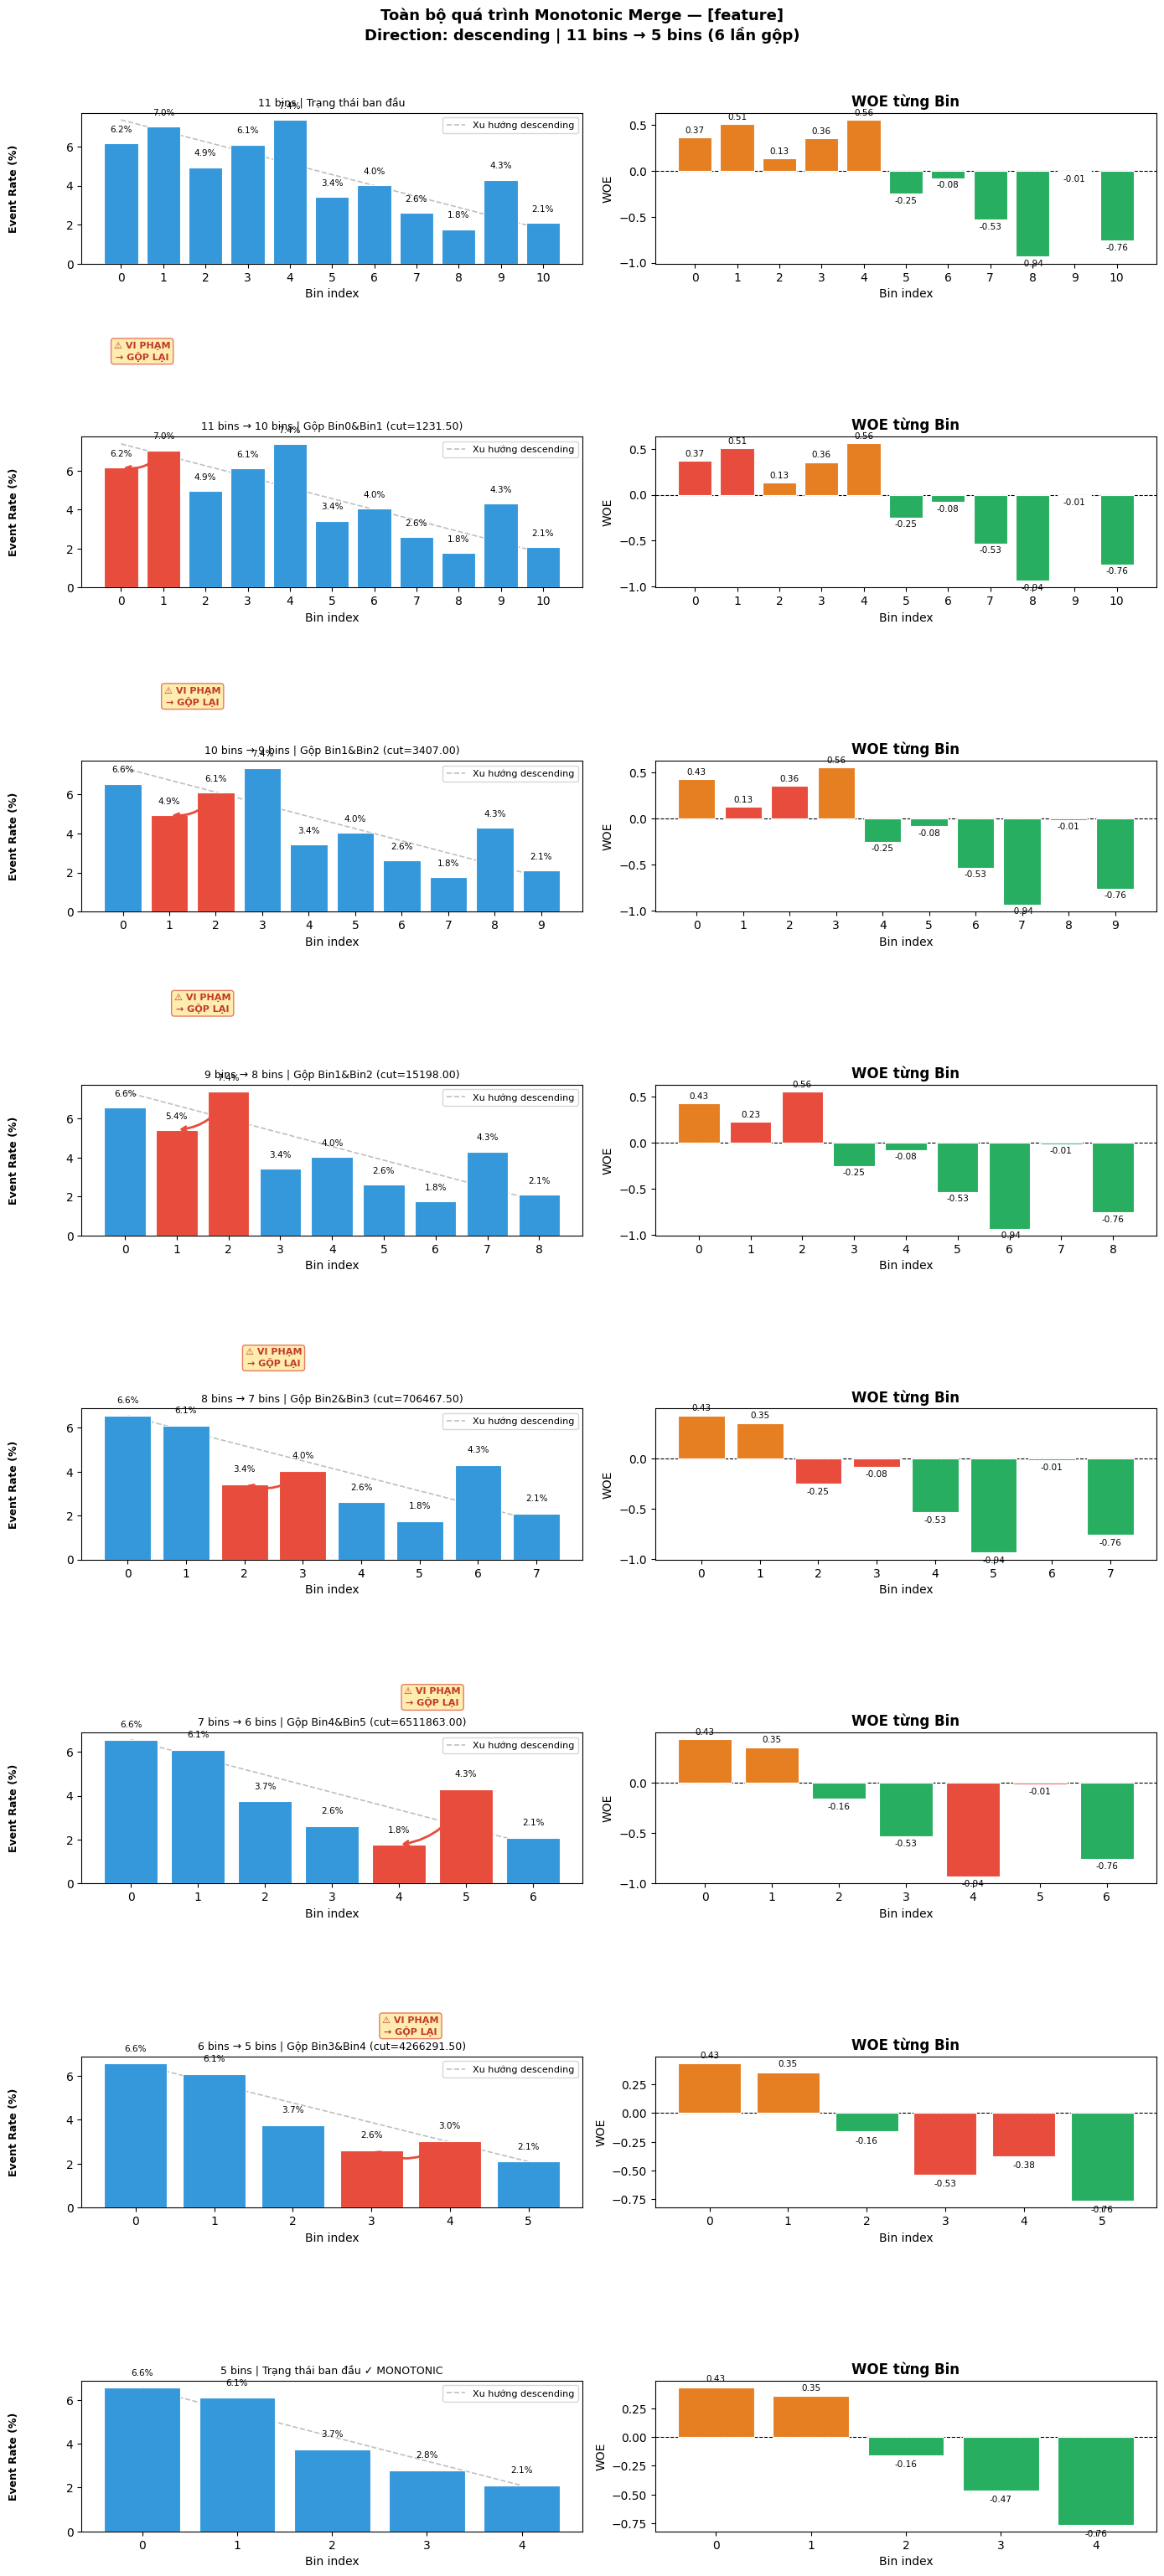

In [20]:
_ = b3.trace_.plot_steps()

In [22]:
result

,Method,IV,n_bins,Monotonic,Direction,IV_Rating,Cuts
0,3. DecisionTree,0.1783,5,✓,descending,Trung bình,"[1705.5, 262126.0, 1199000.0, 10744715.0]"
1,4. ChiMerge,0.1739,7,✓,descending,Trung bình,"[1281.0, 234577.0, 819990.0, 1578247.0, 110958..."
2,1. IsotonicBinner,0.1697,7,✓,descending,Trung bình,"[1323.0, 157808.0, 456166.0, 816000.0, 1207844..."
3,2. QuantileMonotonic,0.1673,6,✓,descending,Trung bình,"[1321.55, 100000.0, 819990.0, 1578247.0, 11945..."
4,5. MDLP,0.1636,2,✓,descending,Trung bình,[262126.0]
